# Toy diagnostic: one space–time interaction surface

This notebook contains **one diagnostic only**: the part of dependence that exists only when a spatial lag and a temporal lag occur together. It deliberately does not diagnose spatial smoothness, nugget, or marginal temporal dependence.

For positive correlations, define the log-additive interaction

$$
\mathcal I(h,\tau)=\log\rho(h,\tau)-\log\rho(h,0)-\log\rho(0,\tau).
$$

It is exactly zero on either axis. Pure spatial and pure temporal dependence are removed using their own marginals. The diagnostic is the standardized residual surface

$$
Z_{ST}(h,\tau)=\frac{\widehat{\mathcal I}(h,\tau)-\mathcal I_{\theta_{fit}}(h,\tau)}{\widehat{\operatorname{se}}\{\widehat{\mathcal I}(h,\tau)\}}.
$$

The toy covariance has a single interaction parameter $\kappa$. All values of $\kappa$ have **identical pure-space and pure-time marginals**, so the experiment cannot be won by a smoothness diagnostic.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 20260803
N_SPACE = 28
N_TIME = 14
N_REP = 800
RANGE_SPACE = 4.5
RANGE_TIME = 3.0
KAPPA_TRUE = -0.60
KAPPA_FIT = 0.00  # deliberately wrong: no tilted space-time interaction
SPACE_LAGS = np.arange(-6, 7)
TIME_LAGS = np.arange(0, 6)
N_BOOT = 400
KAPPA_GRID = np.linspace(-0.90, 0.90, 361)

rng = np.random.default_rng(SEED)
print({
    'n_space': N_SPACE, 'n_time': N_TIME, 'n_replicates': N_REP,
    'kappa_true': KAPPA_TRUE, 'kappa_fitted': KAPPA_FIT,
})

{'n_space': 28, 'n_time': 14, 'n_replicates': 800, 'kappa_true': -0.6, 'kappa_fitted': 0.0}


## Toy covariance with a pure interaction parameter

Let

$$
d_\kappa(h,\tau)^2=\left(\frac{h}{r_s}\right)^2+\left(\frac{\tau}{r_t}\right)^2+2\kappa\left(\frac{h}{r_s}\right)\left(\frac{\tau}{r_t}\right),
\qquad \rho_\kappa(h,\tau)=\exp\{-d_\kappa(h,\tau)\}.
$$

For $|\kappa|<1$ this is an exponential covariance under a positive-definite tilted space–time metric. Because the cross term vanishes at $h=0$ or $\tau=0$, $\rho_\kappa(h,0)$ and $\rho_\kappa(0,\tau)$ do not depend on $\kappa$. Thus $\kappa$ changes only the joint space–time geometry. Expanding the advected distance in the GEMS kernel produces the same kind of $h\tau$ cross term.

In [2]:
def rho_st(h, tau, kappa, range_space=RANGE_SPACE, range_time=RANGE_TIME):
    hs = np.asarray(h, dtype=float) / float(range_space)
    ts = np.asarray(tau, dtype=float) / float(range_time)
    d2 = hs**2 + ts**2 + 2.0 * float(kappa) * hs * ts
    return np.exp(-np.sqrt(np.maximum(d2, 0.0)))


def covariance_matrix(kappa):
    tt, ss = np.meshgrid(np.arange(N_TIME), np.arange(N_SPACE), indexing='ij')
    coords = np.column_stack([ss.ravel(), tt.ravel()])
    h = coords[:, None, 0] - coords[None, :, 0]
    tau = coords[:, None, 1] - coords[None, :, 1]
    cov = rho_st(h, tau, kappa)
    cov.flat[:: cov.shape[0] + 1] += 1e-10
    return cov


cov_true = covariance_matrix(KAPPA_TRUE)
chol_true = np.linalg.cholesky(cov_true)
fields = (rng.standard_normal((N_REP, cov_true.shape[0])) @ chol_true.T).reshape(
    N_REP, N_TIME, N_SPACE
)
print('simulated field array:', fields.shape)

simulated field array: (800, 14, 28)


## Estimate the single interaction surface

Independent replicates make the toy uncertainty calculation transparent. In GEMS, the same role can be played by day × max–min spatial-block clusters, with a block/day bootstrap.

In [3]:
def lag_covariances_by_replicate(field_array, space_lags=SPACE_LAGS, time_lags=TIME_LAGS):
    n_rep, n_time, n_space = field_array.shape
    out = np.empty((n_rep, len(space_lags), len(time_lags)), dtype=float)
    for i, h in enumerate(space_lags):
        if h >= 0:
            x_space = slice(0, n_space - h if h else n_space)
            y_space = slice(h, n_space)
        else:
            x_space = slice(-h, n_space)
            y_space = slice(0, n_space + h)
        for j, tau in enumerate(time_lags):
            x = field_array[:, : n_time - tau if tau else n_time, x_space]
            y = field_array[:, tau:, y_space]
            out[:, i, j] = (x * y).mean(axis=(1, 2))
    variances = (field_array**2).mean(axis=(1, 2))
    return out, variances


def interaction_from_covariance(cov_surface, variance):
    rho = np.asarray(cov_surface, dtype=float) / float(variance)
    h0 = int(np.flatnonzero(SPACE_LAGS == 0)[0])
    t0 = int(np.flatnonzero(TIME_LAGS == 0)[0])
    # The toy is restricted to positive correlations; clipping only protects
    # finite-sample logarithms at the most distant lag.
    log_rho = np.log(np.clip(rho, 1e-5, None))
    interaction = log_rho - log_rho[:, t0][:, None] - log_rho[h0, :][None, :]
    interaction[:, t0] = 0.0
    interaction[h0, :] = 0.0
    return interaction, rho


def model_interaction(kappa):
    hh, tt = np.meshgrid(SPACE_LAGS, TIME_LAGS, indexing='ij')
    rho = rho_st(hh, tt, kappa)
    return interaction_from_covariance(rho, variance=1.0)[0]


cov_by_rep, var_by_rep = lag_covariances_by_replicate(fields)
interaction_hat, rho_hat = interaction_from_covariance(
    cov_by_rep.mean(axis=0), var_by_rep.mean()
)

axis_check = max(
    np.abs(interaction_hat[SPACE_LAGS == 0, :]).max(),
    np.abs(interaction_hat[:, TIME_LAGS == 0]).max(),
)
print(f'max |interaction| on pure-space/pure-time axes: {axis_check:.3e}')

max |interaction| on pure-space/pure-time axes: 0.000e+00


## Infer the interaction parameter from the diagnostic

The bootstrap estimates the covariance of the interaction surface. A generalized least-squares profile then asks which $\kappa$ makes the model-implied interaction closest to the empirical interaction. This turns the plot into an inferential diagnostic: it reports the interaction correction requested by the data, not merely a rejection.

In [4]:
rng_boot = np.random.default_rng(SEED + 1)
interaction_boot = np.empty((N_BOOT, len(SPACE_LAGS), len(TIME_LAGS)), dtype=float)
for b in range(N_BOOT):
    idx = rng_boot.integers(0, N_REP, size=N_REP)
    interaction_boot[b], _ = interaction_from_covariance(
        cov_by_rep[idx].mean(axis=0), var_by_rep[idx].mean()
    )

interior = (SPACE_LAGS[:, None] != 0) & (TIME_LAGS[None, :] > 0)
interaction_vec = interaction_hat[interior]
boot_vec = interaction_boot[:, interior]
omega = np.cov(boot_vec, rowvar=False, ddof=1)
ridge = 1e-3 * np.trace(omega) / omega.shape[0]
omega_inv = np.linalg.pinv(omega + ridge * np.eye(omega.shape[0]))

model_grid = np.stack([model_interaction(k)[interior] for k in KAPPA_GRID])

def q_profile_for_vector(empirical_vec):
    delta = empirical_vec[None, :] - model_grid
    return np.einsum('ki,ij,kj->k', delta, omega_inv, delta, optimize=True)


q_profile = q_profile_for_vector(interaction_vec)
best_idx = int(np.argmin(q_profile))
kappa_diag = float(KAPPA_GRID[best_idx])
kappa_boot = np.empty(N_BOOT, dtype=float)
for b in range(N_BOOT):
    kappa_boot[b] = KAPPA_GRID[np.argmin(q_profile_for_vector(boot_vec[b]))]
ci_low, ci_high = np.quantile(kappa_boot, [0.025, 0.975])

fit_idx = int(np.argmin(np.abs(KAPPA_GRID - KAPPA_FIT)))
true_idx = int(np.argmin(np.abs(KAPPA_GRID - KAPPA_TRUE)))
se_surface = interaction_boot.std(axis=0, ddof=1)
z_fit = np.full_like(interaction_hat, np.nan)
z_true = np.full_like(interaction_hat, np.nan)
z_fit[interior] = (interaction_hat - model_interaction(KAPPA_FIT))[interior] / se_surface[interior]
z_true[interior] = (interaction_hat - model_interaction(KAPPA_TRUE))[interior] / se_surface[interior]

summary = pd.DataFrame([{
    'kappa_fitted': KAPPA_FIT,
    'kappa_diagnostic': kappa_diag,
    'bootstrap_ci_low': ci_low,
    'bootstrap_ci_high': ci_high,
    'kappa_true': KAPPA_TRUE,
    'Q_at_fitted': q_profile[fit_idx],
    'Q_at_diagnostic': q_profile[best_idx],
    'max_abs_Z_fitted': np.nanmax(np.abs(z_fit)),
    'max_abs_Z_true': np.nanmax(np.abs(z_true)),
    'bootstrap_cov_condition': np.linalg.cond(omega + ridge * np.eye(omega.shape[0])),
}])
summary.round(4)

,kappa_fitted,kappa_diagnostic,bootstrap_ci_low,bootstrap_ci_high,kappa_true,Q_at_fitted,Q_at_diagnostic,max_abs_Z_fitted,max_abs_Z_true,bootstrap_cov_condition
0,0.0,-0.595,-0.605,-0.585,-0.6,8012.01,29.1074,60.5807,1.8777,42626.0972


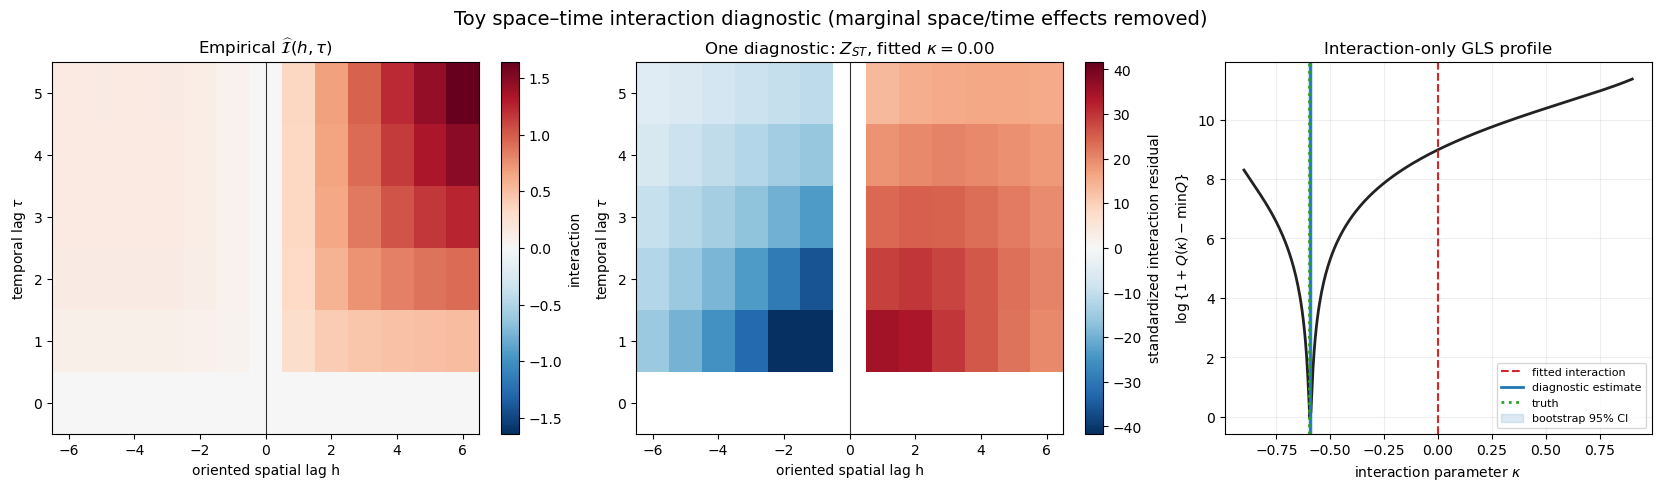

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), constrained_layout=True)

interaction_limit = np.nanmax(np.abs(interaction_hat))
m0 = axes[0].pcolormesh(
    SPACE_LAGS, TIME_LAGS, interaction_hat.T, shading='nearest',
    cmap='RdBu_r', vmin=-interaction_limit, vmax=interaction_limit,
)
axes[0].axvline(0, color='0.2', lw=0.8)
axes[0].set_title(r'Empirical $\widehat{\mathcal{I}}(h,\tau)$')
axes[0].set_xlabel('oriented spatial lag h')
axes[0].set_ylabel(r'temporal lag $\tau$')
fig.colorbar(m0, ax=axes[0], label='interaction')

z_limit = max(3.0, np.nanquantile(np.abs(z_fit), 0.98))
m1 = axes[1].pcolormesh(
    SPACE_LAGS, TIME_LAGS, z_fit.T, shading='nearest',
    cmap='RdBu_r', vmin=-z_limit, vmax=z_limit,
)
axes[1].axvline(0, color='0.2', lw=0.8)
axes[1].set_title(rf'One diagnostic: $Z_{{ST}}$, fitted $\kappa={KAPPA_FIT:.2f}$')
axes[1].set_xlabel('oriented spatial lag h')
axes[1].set_ylabel(r'temporal lag $\tau$')
fig.colorbar(m1, ax=axes[1], label='standardized interaction residual')

axes[2].plot(KAPPA_GRID, np.log1p(q_profile - q_profile.min()), color='#222222', lw=2)
axes[2].axvline(KAPPA_FIT, color='#d62728', ls='--', lw=1.5, label='fitted interaction')
axes[2].axvline(kappa_diag, color='#1f77b4', lw=2, label='diagnostic estimate')
axes[2].axvline(KAPPA_TRUE, color='#2ca02c', ls=':', lw=2, label='truth')
axes[2].axvspan(ci_low, ci_high, color='#1f77b4', alpha=0.15, label='bootstrap 95% CI')
axes[2].set_title('Interaction-only GLS profile')
axes[2].set_xlabel(r'interaction parameter $\kappa$')
axes[2].set_ylabel(r'$\log\{1+Q(\kappa)-\min Q\}$')
axes[2].grid(alpha=0.2)
axes[2].legend(fontsize=8)

fig.suptitle('Toy space–time interaction diagnostic (marginal space/time effects removed)', fontsize=14)
plt.show()

## Reading this one diagnostic

- A correctly specified interaction gives an unstructured $Z_{ST}$ surface centered near zero and a diagnostic interaction estimate compatible with the fitted value.
- A red/blue pattern that reverses between negative and positive spatial lags is the signature of a wrong signed space–time tilt (advection direction or magnitude).
- A symmetric pattern in $h$ that changes with $\tau$ indicates nonseparable interaction not explained by a simple signed tilt.
- Because $\mathcal I(h,0)=\mathcal I(0,\tau)=0$ by construction, this notebook does not re-test smoothness or the marginal temporal covariance.

### Direct GEMS translation

For the corridor kernel, compute empirical and fitted $\rho(h,\tau)$ on oriented longitude/latitude lags and $\tau=1,2$, using the actual observation masks. Bootstrap by day and max–min spatial block. Replace toy $\kappa$ by the interaction directions in the expanded advected metric, chiefly `advec_lat` and `advec_lon`. The production output should remain this same object: one standardized interaction-residual surface plus the interaction-parameter correction inferred from that surface.